In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("26_transaction_fraud.csv")

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Input Features:", X.columns.tolist())
print("Target Variable: is_fraud")
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Input Features: ['transaction_amount_usd', 'hour_of_day', 'num_transactions_today', 'distance_from_home_km', 'employment_type', 'region', 'marital_status']
Target Variable: is_fraud
Training Data: (240, 7)
Testing Data: (60, 7)


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [11]:
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 Fraud Probabilities:")
print(y_prob[:10])

print("\nSigmoid function:")
print("P = 1 / (1 + e^(-z))")
print("\nThe sigmoid function converts the model output into a probability between 0 and 1.")

First 10 Fraud Probabilities:
[0.08884064 0.47539105 0.30887924 0.52393177 0.70691983 0.72800751
 0.42486226 0.19723627 0.07820301 0.284869  ]

Sigmoid function:
P = 1 / (1 + e^(-z))

The sigmoid function converts the model output into a probability between 0 and 1.


In [12]:
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print("First 10 Class Probabilities:")
print(y_prob[:10])

print("\nFirst 10 Predicted Class Labels:")
print(y_pred[:10])

print("\nClassification Threshold:", threshold)
print("Probability >= 0.5 → Fraud (1)")
print("Probability < 0.5 → Genuine (0)")

First 10 Class Probabilities:
[0.08884064 0.47539105 0.30887924 0.52393177 0.70691983 0.72800751
 0.42486226 0.19723627 0.07820301 0.284869  ]

First 10 Predicted Class Labels:
[0 0 0 1 1 1 0 0 0 0]

Classification Threshold: 0.5
Probability >= 0.5 → Fraud (1)
Probability < 0.5 → Genuine (0)


In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[18  8]
 [16 18]]

Accuracy: 0.6

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.69      0.60        26
           1       0.69      0.53      0.60        34

    accuracy                           0.60        60
   macro avg       0.61      0.61      0.60        60
weighted avg       0.62      0.60      0.60        60



AUC Score: 0.7205882352941176


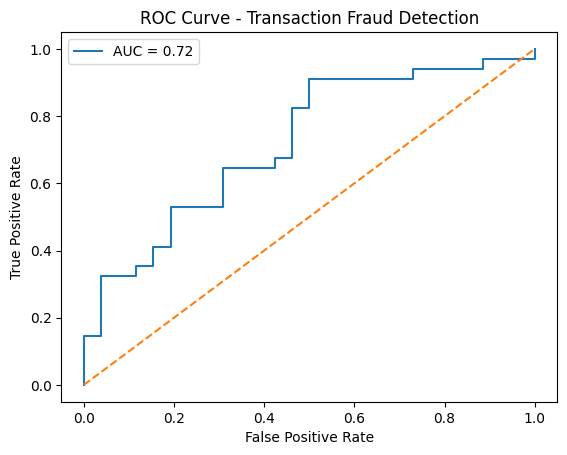

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Transaction Fraud Detection")
plt.legend()
plt.show()

In [15]:
new_threshold = 0.3
y_pred_new = (y_prob >= new_threshold).astype(int)

print("New Threshold:", new_threshold)
print("Number of Fraud Predictions:", y_pred_new.sum())


new_transaction = pd.DataFrame({
    "transaction_amount_usd": [2500],
    "hour_of_day": [2],
    "num_transactions_today": [8],
    "distance_from_home_km": [50],
    "employment_type": ["Full-time"],
    "region": ["North"],
    "marital_status": ["Single"]
})

probability = model.predict_proba(new_transaction)[0, 1]
prediction = int(probability >= 0.5)

print("\nNew Transaction Fraud Probability:", probability)
print("New Transaction Prediction:",
      "Fraud" if prediction == 1 else "Genuine")

New Threshold: 0.3
Number of Fraud Predictions: 47

New Transaction Fraud Probability: 0.17021986122674335
New Transaction Prediction: Genuine
